## Kerasによる基本的なRNNの実装

### ライブラリのimport

In [30]:
# 必要なライブラリのimport
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# DataFrameですべての列を表示する設定
pd.options.display.max_columns = None

# 生成する乱数を固定させる
np.random.seed(seed=0)

### データセットの作成

In [31]:
# サンプリング周波数（1秒あたりのサンプリング数）
F = 100
# 周波数
Hz = 1
# サンプリング秒数
SEC = 5

# sin波の実装
def sin(t):
    return np.sin(2.0 * np.pi * (t * Hz) / F)

In [32]:
# sin波のデータセットを作成
t = np.arange(0, F * SEC + 1)
dataset = sin(t)

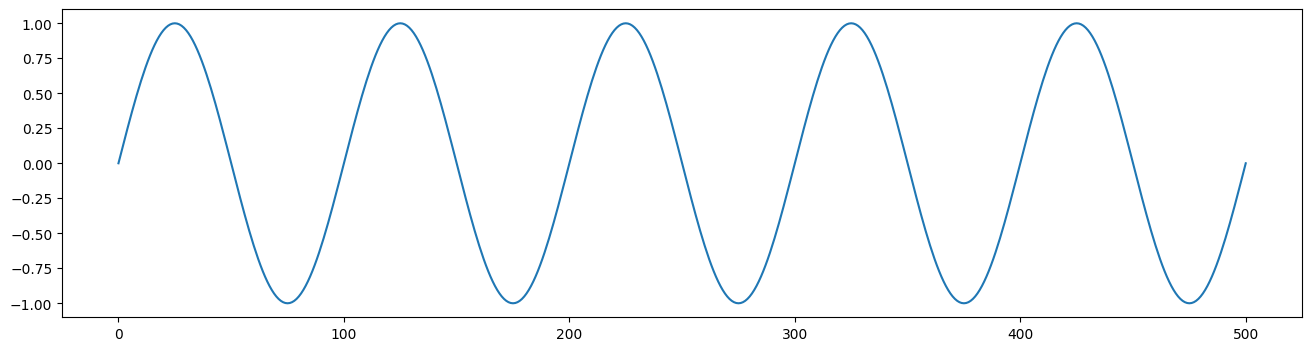

In [33]:
# sin波のグラフ表示
plt.figure(figsize=(16, 4))
plt.plot(t, dataset)

In [34]:
# ノイズを加える
dataset = sin(t) + np.random.normal(loc=0.0, scale=0.1, size=len(t))

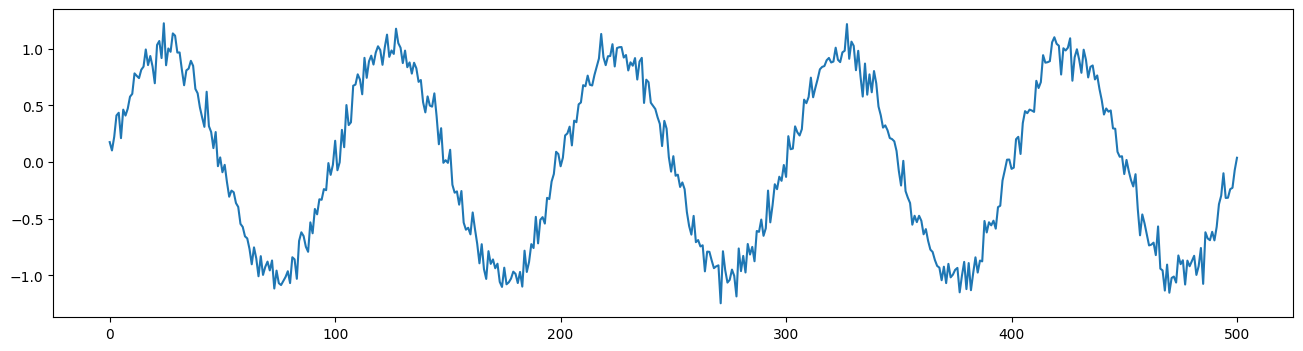

In [35]:
# ノイズを加えたsin波のグラフ表示
plt.figure(figsize=(16, 4))
plt.plot(t, dataset)

### 目的変数と説明変数の作成

In [36]:
# 入力データ長（順伝播の長さ）
T = 20

In [37]:
# 説明変数：目的変数の過去の情報
X = []
# 目的変数
Y = []

# 説明変数と目的変数の作成
for i in range(0, len(dataset) - T):
    X.append(dataset[i:i+T])
    Y.append(dataset[i+T])

In [38]:
# XとYが正しく取得されていることを確認
dataset[0:T+1]

array([0.17640523, 0.10280624, 0.22320703, 0.41147063, 0.43544569,
       0.21128921, 0.46313339, 0.41064357, 0.47143179, 0.57688665,
       0.60218961, 0.78285134, 0.76065088, 0.74113613, 0.81489957,
       0.84238443, 0.99373583, 0.85579085, 0.93613382, 0.84436691,
       0.69575753])

In [39]:
X[0]

array([0.17640523, 0.10280624, 0.22320703, 0.41147063, 0.43544569,
       0.21128921, 0.46313339, 0.41064357, 0.47143179, 0.57688665,
       0.60218961, 0.78285134, 0.76065088, 0.74113613, 0.81489957,
       0.84238443, 0.99373583, 0.85579085, 0.93613382, 0.84436691])

In [40]:
Y[0]

0.6957575347117457

In [41]:
# 学習用にreshape
X = np.array(X).reshape(-1, T, 1)
Y = np.array(Y).reshape(-1, 1)

In [42]:
# 形状を確認
print("Y=", Y.shape, ", X=", X.shape)

Y= (481, 1) , X= (481, 20, 1)


### データの分割

In [43]:
# データの分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=False)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, shuffle=False)

In [44]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (235, 1) , X_train= (235, 20, 1)
Y_valid= (101, 1) , X_valid= (101, 20, 1)
Y_test= (145, 1) , X_test= (145, 20, 1)


### モデルの構築

In [45]:
# 出力数（回帰のため1）
OUT_SIZE = 1
# 隠れ層のユニット数
HIDE_SIZE = 100
# RNNの入力形状: 任意のタイムステップ長, 1つの特徴量
rnn_input_shape = (None, 1)

In [46]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=rnn_input_shape),
    # RNN層
    tf.keras.layers.SimpleRNN(HIDE_SIZE),
    # 出力層
    tf.keras.layers.Dense(OUT_SIZE, activation='linear')
])

# モデルの構築
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss='mean_squared_error')

In [47]:
# 学習の実施
log = model.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                         min_delta=0, patience=100,
                                                         verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/50


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.5044 - val_loss: 0.1125
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0553 - val_loss: 0.0289
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0287 - val_loss: 0.0234
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0231 - val_loss: 0.0172
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0196 - val_loss: 0.0149
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0165 - val_loss: 0.0145
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0161 - val_loss: 0.0139
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0155 - val_loss: 0.0132
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0144 - val_loss: 0.0130
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0140 - val_loss: 0.0166
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0155 - val_loss: 0.0146
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0148 - val_loss: 0.0157
Epoch 13/50


In [48]:
# モデルの構造を表示
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,905 (120.73 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,604 (80.49 KB)

### 学習の経過の確認

Text(0, 0.5, 'crossentropy')

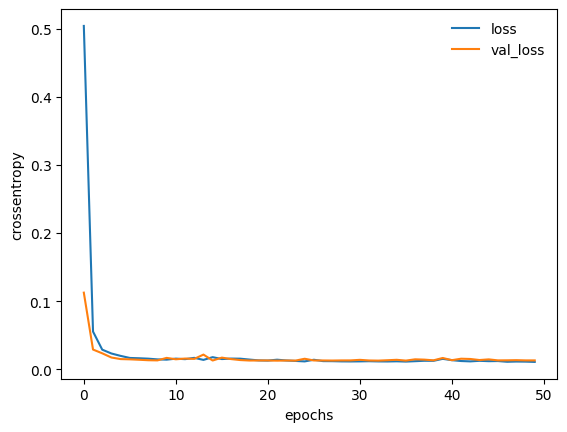

In [49]:
# 学習の経過をグラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

### テストデータによる評価

In [50]:
# 予測
pred_ys = model.predict(X_test)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x140287f60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


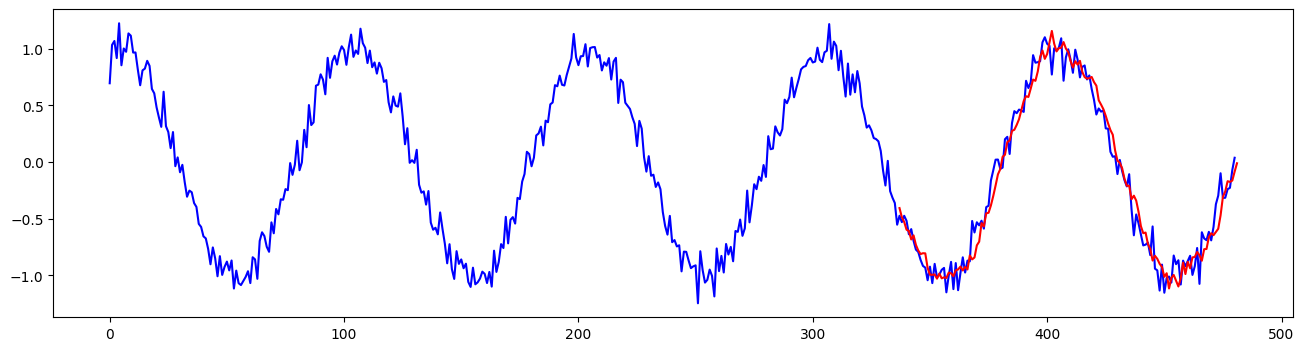

In [51]:
# 正解（青）と予測値（赤）との比較
plt.figure(figsize=(16, 4))
plt.plot(range(0, len(X)), Y, color='blue')
plt.plot(range(len(X_train)+len(X_valid)+1, len(X)+1), pred_ys, color='red')

In [52]:
# MSEを算出
0.5 * ((Y_test - pred_ys) ** 2).sum()

0.9282755142283863

## LSTMの実装

### モデルの構築

In [53]:
# モデルの初期化
model_lstm = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=rnn_input_shape),
    # RNN層
    tf.keras.layers.LSTM(HIDE_SIZE),
    # 出力層
    tf.keras.layers.Dense(OUT_SIZE, activation='linear')
])

# モデルの構築
model_lstm.compile(optimizer = tf.keras.optimizers.Adam(),
                   loss='mean_squared_error')

In [54]:
# 学習の実施
log_lstm = model_lstm.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=True,
                          callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                                      min_delta=0, patience=100,
                                                                      verbose=1)],
                          validation_data=(X_valid, Y_valid))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.4666 - val_loss: 0.1906
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1497 - val_loss: 0.1116
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0890 - val_loss: 0.0741
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0639 - val_loss: 0.0445
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0342 - val_loss: 0.0232
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0167 - val_loss: 0.0140
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0143 - val_loss: 0.0148
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0143 - val_loss: 0.0136
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0126 - val_loss: 0.0128
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0131 - val_loss: 0.0124
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0130 - val_loss: 0.0114
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0124 - val_loss: 0.0119
E

In [55]:
# モデルの構造を表示
model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,705 (479.32 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,804 (319.55 KB)

### 学習の経過の確認

Text(0, 0.5, 'crossentropy')

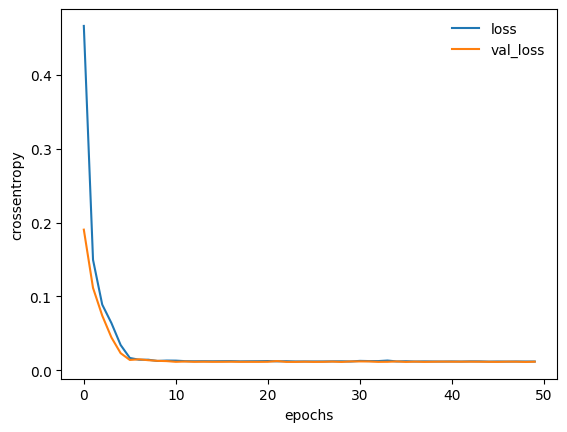

In [56]:
# 学習の経過をグラフ表示
plt.plot(log_lstm.history['loss'], label='loss')
plt.plot(log_lstm.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

### テストデータによる評価

In [59]:
# 予測
pred_ys_lstm = model_lstm.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


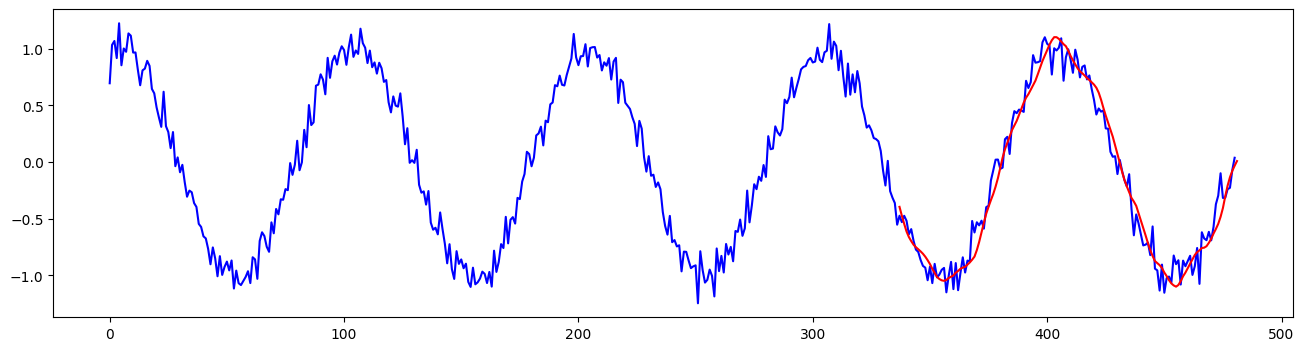

In [60]:
# 正解（青）と予測値（赤）との比較
plt.figure(figsize=(16, 4))
plt.plot(range(0, len(X)), Y, color='blue')
plt.plot(range(len(X_train)+len(X_valid)+1, len(X)+1), pred_ys_lstm, color='red')